# 16. TEP (Tennessee Eastman Process) 고장 탐지 ML
테네시 이스트만 공정 센서 데이터를 활용한 이진 분류 — 정상(0) vs. 고장(1)

In [1]:
# ── 라이브러리 import & 설정 ─────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
import pickle, warnings, time
warnings.filterwarnings('ignore')

from pathlib import Path
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, roc_curve, classification_report
)
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

# 한글 폰트 설정 (Malgun Gothic)
font_path = r'C:\Windows\Fonts\malgun.ttf'
font_prop = fm.FontProperties(fname=font_path)
plt.rcParams['font.family'] = font_prop.get_name()
plt.rcParams['axes.unicode_minus'] = False

# 프로젝트 표준 컬러 팔레트
COLORS = ['#3498db', '#e74c3c', '#2ecc71', '#f1c40f', '#e67e22']

# 경로 설정
BASE   = Path(r'G:\내 드라이브\강의자료\Vibe_Coding\Datascience\Test\16_TEP_ML')
RES    = BASE / 'resources'
OUTPUT = BASE / 'output'
OUTPUT.mkdir(parents=True, exist_ok=True)  # output/ 디렉토리 자동 생성

RANDOM_SEED = 42
print('라이브러리 로드 완료')
print(f'출력 경로: {OUTPUT}')

라이브러리 로드 완료
출력 경로: G:\내 드라이브\강의자료\Vibe_Coding\Datascience\Test\16_TEP_ML\output


## 1. 데이터 로드 & 탐색 (샘플링 포함)

In [2]:
# ── 피처 컬럼 정의 (메타데이터 제외) ────────────────
FEAT_COLS = [f'xmeas_{i}' for i in range(1, 42)] + \
            [f'xmv_{i}'   for i in range(1, 12)]
LABEL_COL = 'label'

# 샘플링 크기: 정상/고장 각 50K씩 → 학습 100K, 테스트 40K
N_TRAIN = 50_000
N_TEST  = 20_000

def load_and_sample(filepath, n_sample, label_value, seed=RANDOM_SEED, chunksize=200_000):
    """청크 단위로 읽어 메모리 효율적으로 샘플링"""
    use_cols = ['faultNumber'] + FEAT_COLS
    chunks = []
    for chunk in pd.read_csv(filepath, usecols=use_cols, chunksize=chunksize):
        chunks.append(chunk)
    df_all = pd.concat(chunks, ignore_index=True)
    if len(df_all) > n_sample:
        df_all = df_all.sample(n=n_sample, random_state=seed)
    df_all[LABEL_COL] = label_value
    return df_all[FEAT_COLS + [LABEL_COL]].reset_index(drop=True)

print('샘플링 시작...')
t_start = time.time()

print('  [1/4] FaultFree_Training (정상, 학습)...')
df_ff_train = load_and_sample(RES / 'TEP_FaultFree_Training.csv', N_TRAIN, label_value=0)

print('  [2/4] Faulty_Training (고장, 학습)...')
df_fa_train = load_and_sample(RES / 'TEP_Faulty_Training.csv',    N_TRAIN, label_value=1)

print('  [3/4] FaultFree_Testing (정상, 테스트)...')
df_ff_test  = load_and_sample(RES / 'TEP_FaultFree_Testing.csv',  N_TEST,  label_value=0)

print('  [4/4] Faulty_Testing (고장, 테스트)...')
df_fa_test  = load_and_sample(RES / 'TEP_Faulty_Testing.csv',     N_TEST,  label_value=1)

# 학습/테스트 세트 결합 & 셔플
df_train = pd.concat([df_ff_train, df_fa_train], ignore_index=True)\
             .sample(frac=1, random_state=RANDOM_SEED).reset_index(drop=True)
df_test  = pd.concat([df_ff_test,  df_fa_test],  ignore_index=True)\
             .sample(frac=1, random_state=RANDOM_SEED).reset_index(drop=True)

print(f'\n샘플링 완료: {time.time()-t_start:.1f}초')
print(f'\n=== 학습 데이터 ===')
print(f'  Shape: {df_train.shape}')
print(f'  레이블 분포:\n{df_train[LABEL_COL].value_counts().rename({0:"정상", 1:"고장"})}')
print(f'  결측값: {df_train.isnull().sum().sum()}')
print(f'\n=== 테스트 데이터 ===')
print(f'  Shape: {df_test.shape}')
print(f'  레이블 분포:\n{df_test[LABEL_COL].value_counts().rename({0:"정상", 1:"고장"})}')
print(f'\n=== 피처 기술통계 (상위 5개) ===')
display(df_train[FEAT_COLS[:5]].describe().round(4))

샘플링 시작...
  [1/4] FaultFree_Training (정상, 학습)...


  [2/4] Faulty_Training (고장, 학습)...


  [3/4] FaultFree_Testing (정상, 테스트)...


  [4/4] Faulty_Testing (고장, 테스트)...



샘플링 완료: 170.1초

=== 학습 데이터 ===
  Shape: (100000, 53)
  레이블 분포:
label
고장    50000
정상    50000
Name: count, dtype: int64
  결측값: 0

=== 테스트 데이터 ===
  Shape: (40000, 53)
  레이블 분포:
label
고장    20000
정상    20000
Name: count, dtype: int64

=== 피처 기술통계 (상위 5개) ===


,xmeas_1,xmeas_2,xmeas_3,xmeas_4,xmeas_5
count,100000.0000,100000.0000,100000.0000,100000.0000,100000.0000
mean,0.2559,3663.6904,4507.3337,9.3566,26.9028
std,0.1076,38.6713,83.2989,0.2632,0.2222
min,-0.0037,3372.3000,3767.6000,6.9216,25.5480
25%,0.2256,3638.8000,4476.9000,9.2783,26.7610
50%,0.2508,3663.4000,4508.7000,9.3498,26.9020
75%,0.2758,3688.3000,4540.3000,9.4225,27.0460
max,1.0135,3859.7000,5110.4000,12.2190,28.1880


## 2. EDA 시각화

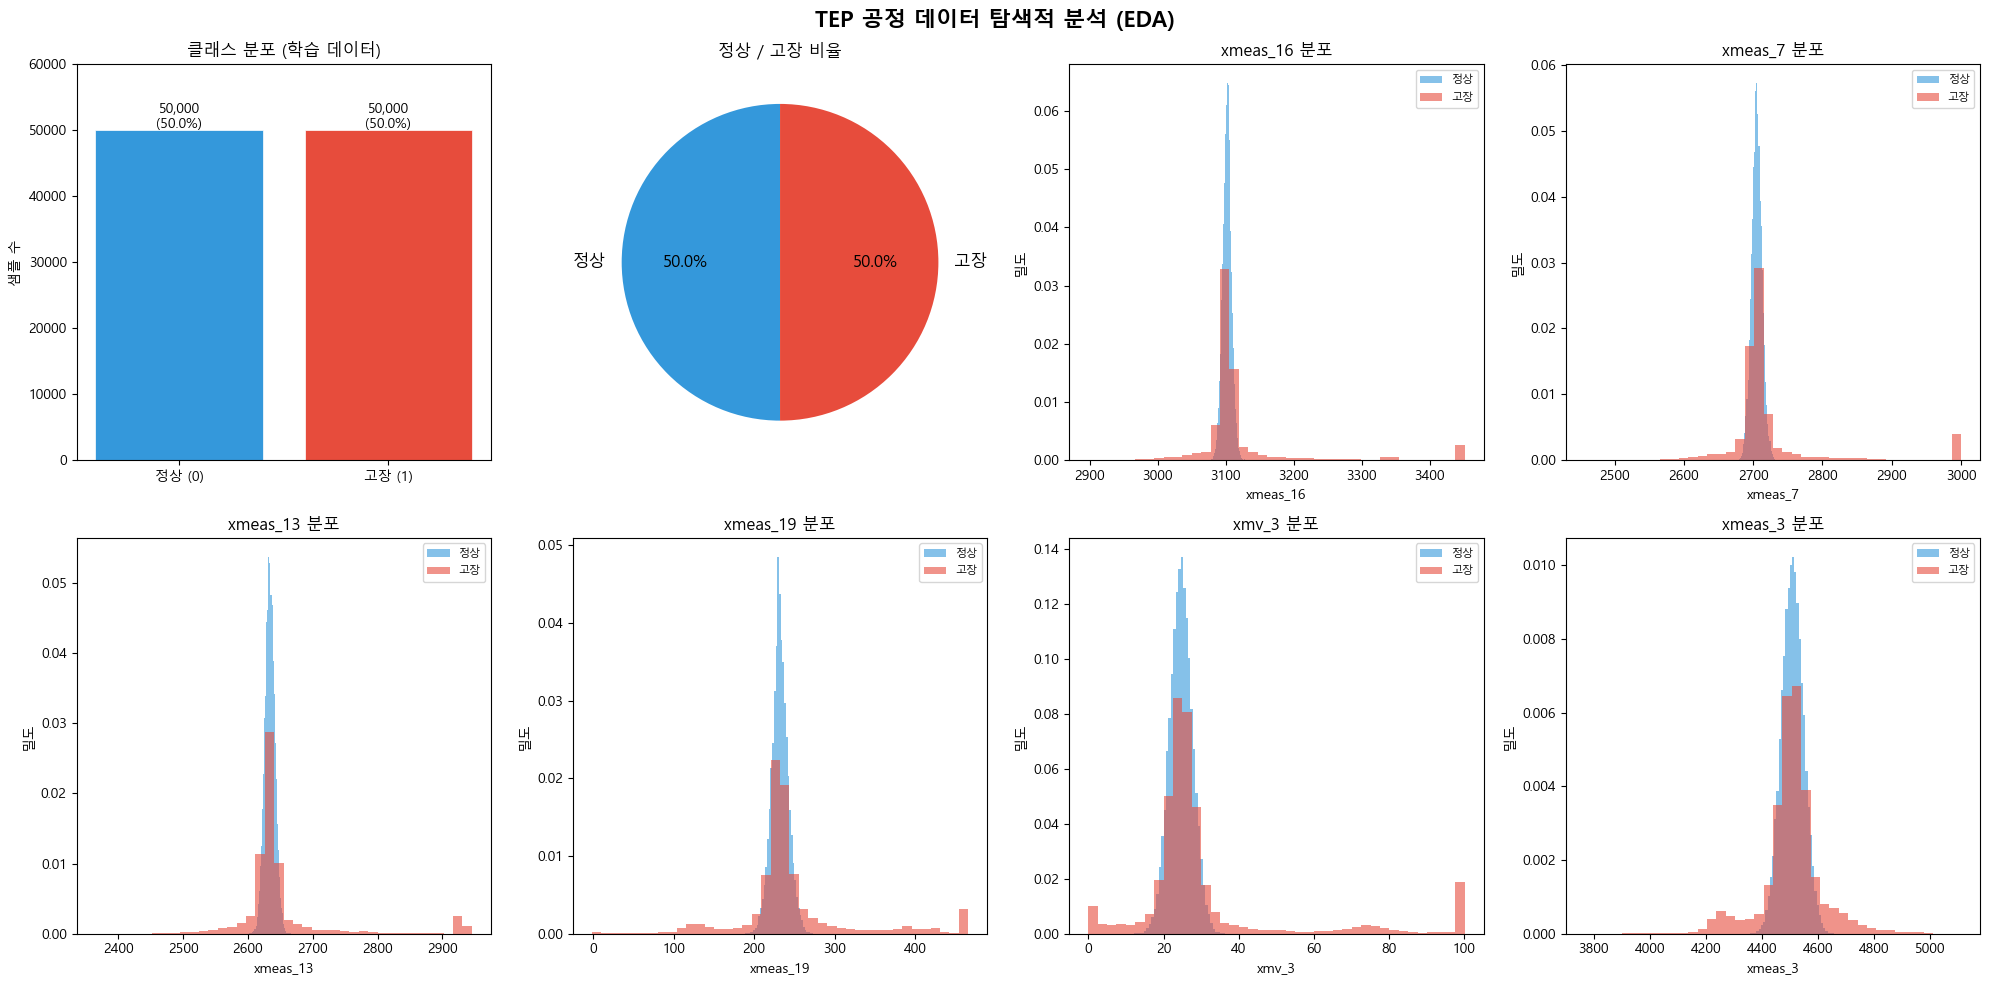

저장: 01_eda.png
판별력 높은 상위 6개 피처: ['xmeas_16', 'xmeas_7', 'xmeas_13', 'xmeas_19', 'xmv_3', 'xmeas_3']


In [3]:
# ── EDA 시각화 → 01_eda.png ──────────────────────────
# 정상/고장 간 평균 차이가 큰 상위 6개 피처 선택
top6_feats = (
    df_train.groupby(LABEL_COL)[FEAT_COLS]
    .mean().diff().iloc[-1].abs()
    .nlargest(6).index.tolist()
)

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
fig.suptitle('TEP 공정 데이터 탐색적 분석 (EDA)', fontsize=16, fontweight='bold')

# [0,0] 클래스 분포 막대
class_counts = df_train[LABEL_COL].value_counts().sort_index()
bars = axes[0,0].bar(['정상 (0)', '고장 (1)'], class_counts.values,
                     color=[COLORS[0], COLORS[1]], edgecolor='white', linewidth=0.5)
for bar, v in zip(bars, class_counts.values):
    axes[0,0].text(bar.get_x()+bar.get_width()/2, v + 300,
                   f'{v:,}\n({v/len(df_train)*100:.1f}%)', ha='center', fontsize=10)
axes[0,0].set_title('클래스 분포 (학습 데이터)')
axes[0,0].set_ylabel('샘플 수')
axes[0,0].set_ylim(0, max(class_counts.values) * 1.2)

# [0,1] 파이 차트
axes[0,1].pie(class_counts.values, labels=['정상', '고장'],
              autopct='%1.1f%%', colors=[COLORS[0], COLORS[1]],
              startangle=90, textprops={'fontsize': 12})
axes[0,1].set_title('정상 / 고장 비율')

# [0,2]~[1,3] 상위 6개 피처 분포 히스토그램
for idx, feat in enumerate(top6_feats):
    row, col = divmod(idx + 2, 4)
    ax = axes[row, col]
    for lbl, color, name in [(0, COLORS[0], '정상'), (1, COLORS[1], '고장')]:
        ax.hist(df_train[df_train[LABEL_COL]==lbl][feat],
                bins=40, alpha=0.6, color=color, label=name, density=True)
    ax.set_title(f'{feat} 분포')
    ax.set_xlabel(feat)
    ax.set_ylabel('밀도')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(OUTPUT / '01_eda.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'저장: 01_eda.png')
print(f'판별력 높은 상위 6개 피처: {top6_feats}')

## 3. 전처리

In [4]:
# ── 전처리 (StandardScaler 적용) ─────────────────────
X_train = df_train[FEAT_COLS].values
y_train = df_train[LABEL_COL].values
X_test  = df_test[FEAT_COLS].values
y_test  = df_test[LABEL_COL].values

# 학습 데이터로만 fit → 테스트는 transform만 (데이터 누수 방지)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print('=== 전처리 완료 ===')
print(f'X_train: {X_train_sc.shape}  y_train: {y_train.shape}')
print(f'X_test:  {X_test_sc.shape}   y_test:  {y_test.shape}')
print(f'학습 레이블: 정상={np.sum(y_train==0):,}, 고장={np.sum(y_train==1):,}')
print(f'테스트 레이블: 정상={np.sum(y_test==0):,}, 고장={np.sum(y_test==1):,}')

=== 전처리 완료 ===
X_train: (100000, 52)  y_train: (100000,)
X_test:  (40000, 52)   y_test:  (40000,)
학습 레이블: 정상=50,000, 고장=50,000
테스트 레이블: 정상=20,000, 고장=20,000


## 4. 모델 학습 & 비교

In [5]:
# ── 4개 모델 정의 ───────────────────────────────────
# use_scale=True: Logistic Regression은 스케일 적용 필요
# 트리 계열(RF, LGBM, XGB)은 스케일 불필요
models = {
    '로지스틱 회귀': (
        LogisticRegression(C=1.0, max_iter=1000, solver='lbfgs',
                           random_state=RANDOM_SEED),
        True   # 스케일된 데이터 사용
    ),
    '랜덤 포레스트': (
        RandomForestClassifier(n_estimators=200, max_depth=None,
                               min_samples_split=2, n_jobs=-1,
                               random_state=RANDOM_SEED),
        False
    ),
    'LightGBM': (
        LGBMClassifier(n_estimators=300, learning_rate=0.05,
                       max_depth=-1, num_leaves=63,
                       subsample=0.8, colsample_bytree=0.8,
                       n_jobs=-1, random_state=RANDOM_SEED,
                       verbose=-1),
        False
    ),
    'XGBoost': (
        XGBClassifier(n_estimators=200, learning_rate=0.1,
                      max_depth=6, subsample=0.8,
                      colsample_bytree=0.8, n_jobs=-1,
                      random_state=RANDOM_SEED,
                      eval_metric='logloss', verbosity=0),
        False
    ),
}

# 5-Fold 층화 교차검증 (학습 데이터 기준)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)

results = {}
print(f'{"모델":<14} | {"Acc":>6} | {"Prec":>6} | {"Rec":>6} | {"F1":>6} | {"AUC":>6} | {"CV-AUC":>10} | {"시간":>6}')
print('-' * 85)

for name, (model, use_scale) in models.items():
    Xtr = X_train_sc if use_scale else X_train
    Xte = X_test_sc  if use_scale else X_test

    t0 = time.time()
    model.fit(Xtr, y_train)
    elapsed = time.time() - t0

    y_pred = model.predict(Xte)
    y_prob = model.predict_proba(Xte)[:, 1]

    # 교차검증 (AUC 기준)
    cv_scores = cross_val_score(model, Xtr, y_train,
                                cv=cv, scoring='roc_auc', n_jobs=-1)

    results[name] = {
        'model':       model,
        'use_scale':   use_scale,
        'y_pred':      y_pred,
        'y_prob':      y_prob,
        'accuracy':    accuracy_score(y_test, y_pred),
        'precision':   precision_score(y_test, y_pred),
        'recall':      recall_score(y_test, y_pred),
        'f1':          f1_score(y_test, y_pred),
        'auc':         roc_auc_score(y_test, y_prob),
        'cv_auc_mean': cv_scores.mean(),
        'cv_auc_std':  cv_scores.std(),
        'elapsed':     elapsed,
    }
    r = results[name]
    print(f'{name:<14} | {r["accuracy"]:>6.4f} | {r["precision"]:>6.4f} | '
          f'{r["recall"]:>6.4f} | {r["f1"]:>6.4f} | {r["auc"]:>6.4f} | '
          f'{r["cv_auc_mean"]:>5.4f}±{r["cv_auc_std"]:.4f} | {elapsed:>5.1f}s')

모델             |    Acc |   Prec |    Rec |     F1 |    AUC |     CV-AUC |     시간
-------------------------------------------------------------------------------------


로지스틱 회귀        | 0.6910 | 0.7902 | 0.5201 | 0.6273 | 0.7076 | 0.7389±0.0032 |   3.1s


랜덤 포레스트        | 0.8048 | 0.9550 | 0.6397 | 0.7662 | 0.8364 | 0.8744±0.0017 |  93.1s


LightGBM       | 0.8153 | 0.9738 | 0.6480 | 0.7782 | 0.8451 | 0.8932±0.0023 |   9.1s


XGBoost        | 0.8141 | 0.9772 | 0.6432 | 0.7758 | 0.8438 | 0.8948±0.0027 |   4.1s


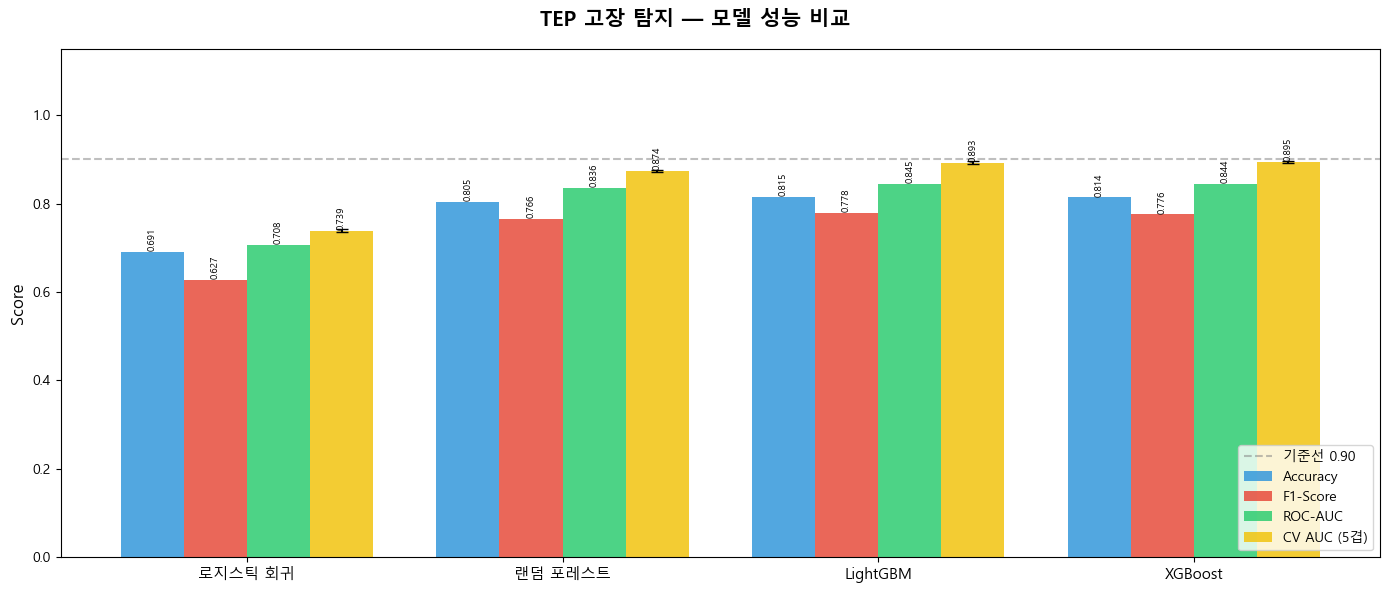

저장: 02_model_comparison.png


In [6]:
# ── 모델 비교 차트 → 02_model_comparison.png ─────────
model_names = list(results.keys())
acc_vals = [results[n]['accuracy']    for n in model_names]
f1_vals  = [results[n]['f1']          for n in model_names]
auc_vals = [results[n]['auc']         for n in model_names]
cv_vals  = [results[n]['cv_auc_mean'] for n in model_names]
cv_stds  = [results[n]['cv_auc_std']  for n in model_names]

x = np.arange(len(model_names))
width = 0.20

fig, ax = plt.subplots(figsize=(14, 6))
fig.suptitle('TEP 고장 탐지 — 모델 성능 비교', fontsize=15, fontweight='bold')

b1 = ax.bar(x - 1.5*width, acc_vals, width, label='Accuracy',    color=COLORS[0], alpha=0.85)
b2 = ax.bar(x - 0.5*width, f1_vals,  width, label='F1-Score',    color=COLORS[1], alpha=0.85)
b3 = ax.bar(x + 0.5*width, auc_vals, width, label='ROC-AUC',     color=COLORS[2], alpha=0.85)
b4 = ax.bar(x + 1.5*width, cv_vals,  width, label='CV AUC (5겹)', color=COLORS[3], alpha=0.85,
            yerr=cv_stds, capsize=4, error_kw={'elinewidth': 1.5})

# 막대 위에 수치 표시
for bars in [b1, b2, b3, b4]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x()+bar.get_width()/2, h + 0.002,
                f'{h:.3f}', ha='center', va='bottom', fontsize=7, rotation=90)

ax.axhline(0.9, color='gray', linestyle='--', alpha=0.5, label='기준선 0.90')
ax.set_xticks(x)
ax.set_xticklabels(model_names, fontsize=11)
ax.set_ylim(0, 1.15)
ax.set_ylabel('Score', fontsize=12)
ax.legend(fontsize=10, loc='lower right')

plt.tight_layout()
plt.savefig(OUTPUT / '02_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('저장: 02_model_comparison.png')

## 5. 최적 모델 분석

In [7]:
# ── AUC 기준 최적 모델 선택 ──────────────────────────
best_name = max(results, key=lambda n: results[n]['auc'])
best = results[best_name]

print(f'=== 최적 모델: {best_name} ===')
print(f'  Accuracy:  {best["accuracy"]:.4f}')
print(f'  Precision: {best["precision"]:.4f}')
print(f'  Recall:    {best["recall"]:.4f}')
print(f'  F1-Score:  {best["f1"]:.4f}')
print(f'  ROC-AUC:   {best["auc"]:.4f}')
print(f'  CV AUC:    {best["cv_auc_mean"]:.4f} ± {best["cv_auc_std"]:.4f}')
print()
print('--- 분류 리포트 ---')
print(classification_report(y_test, best['y_pred'], target_names=['정상', '고장']))

=== 최적 모델: LightGBM ===
  Accuracy:  0.8153
  Precision: 0.9738
  Recall:    0.6480
  F1-Score:  0.7782
  ROC-AUC:   0.8451
  CV AUC:    0.8932 ± 0.0023

--- 분류 리포트 ---
              precision    recall  f1-score   support

          정상       0.74      0.98      0.84     20000
          고장       0.97      0.65      0.78     20000

    accuracy                           0.82     40000
   macro avg       0.86      0.82      0.81     40000
weighted avg       0.86      0.82      0.81     40000



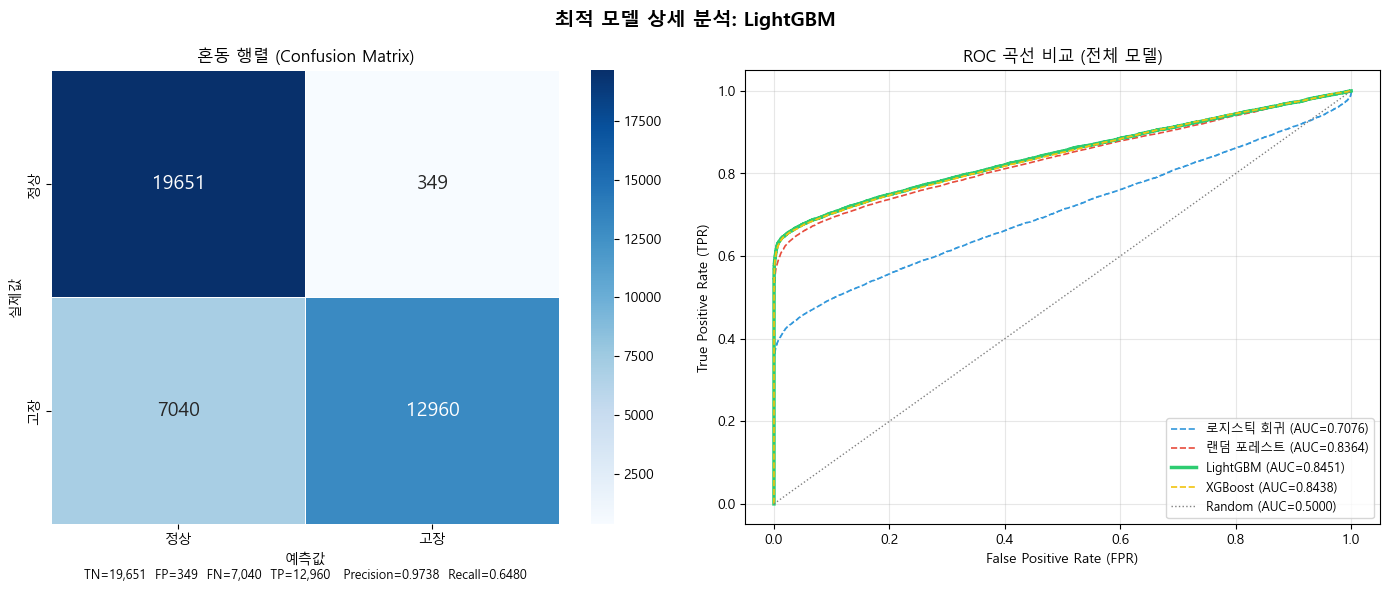

저장: 03_best_model_analysis.png


In [8]:
# ── 혼동 행렬 + ROC 곡선 → 03_best_model_analysis.png ─
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle(f'최적 모델 상세 분석: {best_name}', fontsize=14, fontweight='bold')

# [왼쪽] 혼동 행렬
cm = confusion_matrix(y_test, best['y_pred'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['정상', '고장'], yticklabels=['정상', '고장'],
            linewidths=0.5, annot_kws={'size': 14})
axes[0].set_title('혼동 행렬 (Confusion Matrix)')
axes[0].set_xlabel('예측값')
axes[0].set_ylabel('실제값')
tn, fp, fn, tp = cm.ravel()
axes[0].text(0.5, -0.12,
             f'TN={tn:,}  FP={fp:,}  FN={fn:,}  TP={tp:,}   '
             f'Precision={tp/(tp+fp):.4f}  Recall={tp/(tp+fn):.4f}',
             transform=axes[0].transAxes, ha='center', fontsize=9)

# [오른쪽] 4개 모델 ROC 곡선 비교
for name, color in zip(results.keys(), COLORS):
    fpr, tpr, _ = roc_curve(y_test, results[name]['y_prob'])
    auc_val = results[name]['auc']
    lw = 2.5 if name == best_name else 1.2
    ls = '-'  if name == best_name else '--'
    axes[1].plot(fpr, tpr, color=color, lw=lw, ls=ls,
                 label=f'{name} (AUC={auc_val:.4f})')

axes[1].plot([0,1], [0,1], 'gray', linestyle=':', lw=1, label='Random (AUC=0.5000)')
axes[1].set_xlabel('False Positive Rate (FPR)')
axes[1].set_ylabel('True Positive Rate (TPR)')
axes[1].set_title('ROC 곡선 비교 (전체 모델)')
axes[1].legend(fontsize=9, loc='lower right')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT / '03_best_model_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('저장: 03_best_model_analysis.png')

## 6. 피처 중요도

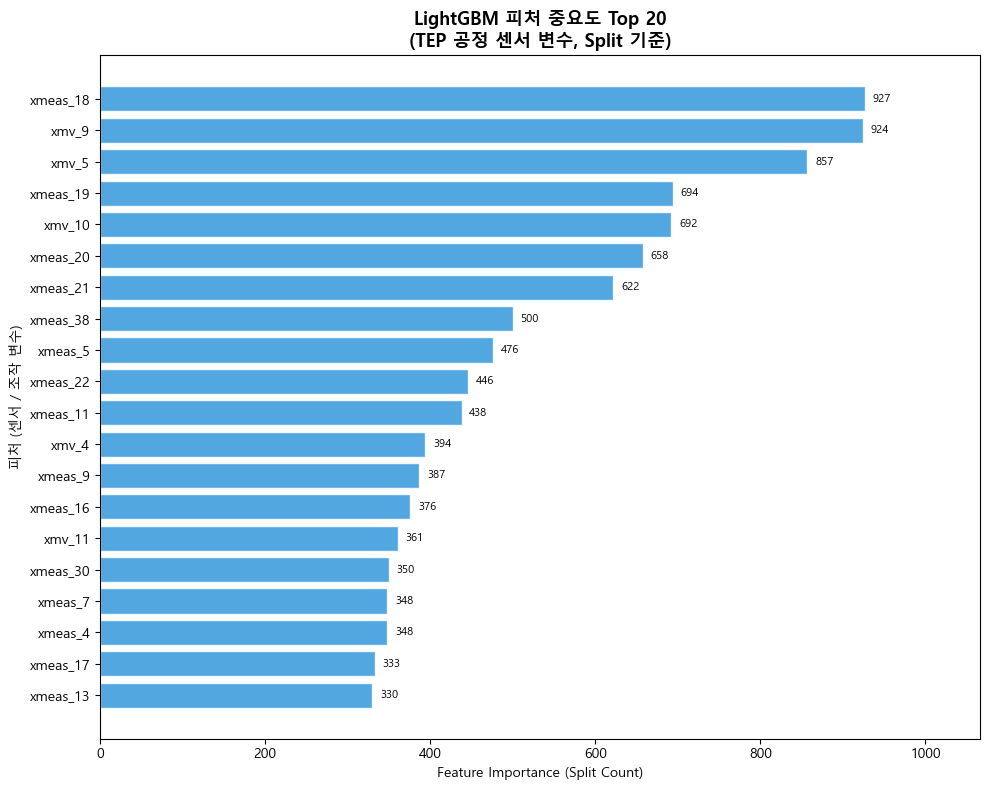

저장: 04_feature_importance.png


In [9]:
# ── LightGBM 피처 중요도 → 04_feature_importance.png ─
lgbm_model = results['LightGBM']['model']
importances = lgbm_model.feature_importances_  # split 기준

feat_df = pd.DataFrame({'피처': FEAT_COLS, '중요도': importances})\
            .sort_values('중요도', ascending=True).tail(20)

fig, ax = plt.subplots(figsize=(10, 8))
bars = ax.barh(feat_df['피처'], feat_df['중요도'],
               color=COLORS[0], alpha=0.85, edgecolor='white')

# 막대 끝에 수치 표시
max_imp = importances.max()
for bar in bars:
    w = bar.get_width()
    ax.text(w + max_imp*0.01, bar.get_y()+bar.get_height()/2,
            f'{int(w):,}', va='center', fontsize=8)

ax.set_title('LightGBM 피처 중요도 Top 20\n(TEP 공정 센서 변수, Split 기준)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Feature Importance (Split Count)')
ax.set_ylabel('피처 (센서 / 조작 변수)')
ax.set_xlim(0, max_imp * 1.15)

plt.tight_layout()
plt.savefig(OUTPUT / '04_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('저장: 04_feature_importance.png')

## 7. 모델 저장

In [10]:
# ── PKL 번들 저장 ────────────────────────────────────
model_bundle = {
    'model':         best['model'],
    'model_name':    best_name,
    'scaler':        scaler,
    'feature_names': FEAT_COLS,
    'label_map':     {0: '정상', 1: '고장'},
    'performance': {
        'accuracy':      best['accuracy'],
        'precision':     best['precision'],
        'recall':        best['recall'],
        'f1':            best['f1'],
        'roc_auc':       best['auc'],
        'cv_auc_mean':   best['cv_auc_mean'],
        'cv_auc_std':    best['cv_auc_std'],
    },
    'train_samples': len(df_train),
    'test_samples':  len(df_test),
}

pkl_path = OUTPUT / 'tep_model.pkl'
with open(pkl_path, 'wb') as f:
    pickle.dump(model_bundle, f)

print(f'모델 저장 완료: {pkl_path}')
print(f'  모델: {best_name}')
print(f'  피처 수: {len(FEAT_COLS)}')
print(f'  학습 샘플: {len(df_train):,}')

# 저장 검증 — 로드 후 5개 샘플 예측
with open(pkl_path, 'rb') as f:
    loaded = pickle.load(f)

sample_X = X_test_sc[:5] if loaded['model_name'] == '로지스틱 회귀' else X_test[:5]
sample_pred = loaded['model'].predict(sample_X)
sample_prob = loaded['model'].predict_proba(sample_X)[:, 1]
print(f'\n검증 예측 (5개 샘플):')
for i, (pred, prob, actual) in enumerate(zip(sample_pred, sample_prob, y_test[:5])):
    label    = loaded['label_map'][pred]
    act_label = loaded['label_map'][actual]
    correct  = '✓' if pred == actual else '✗'
    print(f'  샘플{i+1}: 예측={label}({prob:.4f}), 실제={act_label} {correct}')

모델 저장 완료: G:\내 드라이브\강의자료\Vibe_Coding\Datascience\Test\16_TEP_ML\output\tep_model.pkl
  모델: LightGBM
  피처 수: 52
  학습 샘플: 100,000



검증 예측 (5개 샘플):
  샘플1: 예측=정상(0.1901), 실제=고장 ✗
  샘플2: 예측=정상(0.3163), 실제=정상 ✓
  샘플3: 예측=정상(0.1935), 실제=고장 ✗
  샘플4: 예측=정상(0.2374), 실제=정상 ✓
  샘플5: 예측=고장(0.9979), 실제=고장 ✓


## 8. 결과 요약

In [11]:
# ── 최종 결과 요약 ───────────────────────────────────
print('=' * 62)
print('   TEP 고장 탐지 ML 파이프라인 — 최종 결과 요약')
print('=' * 62)
print(f'  데이터: 학습 {len(df_train):,}행 / 테스트 {len(df_test):,}행')
print(f'  피처:   {len(FEAT_COLS)}개 (xmeas 41개 + xmv 11개)')
print(f'  문제:   이진 분류 (정상=0 / 고장=1)')
print()
print(f'  {"모델":<14} | {"Accuracy":>8} | {"F1":>6} | {"AUC":>6} | {"CV-AUC":>7}')
print('  ' + '-' * 52)
for name in results:
    r = results[name]
    marker = ' ★' if name == best_name else ''
    print(f'  {name:<14} | {r["accuracy"]:>8.4f} | {r["f1"]:>6.4f} | '
          f'{r["auc"]:>6.4f} | {r["cv_auc_mean"]:>6.4f}{marker}')
print()
print(f'  최적 모델: {best_name}')
print(f'  ROC-AUC:   {best["auc"]:.4f}')
print(f'  F1-Score:  {best["f1"]:.4f}')
print()
print('  출력 파일:')
for fname in ['01_eda.png', '02_model_comparison.png',
              '03_best_model_analysis.png', '04_feature_importance.png',
              'tep_model.pkl']:
    exists = '✓' if (OUTPUT / fname).exists() else '✗'
    print(f'    [{exists}] {fname}')
print('=' * 62)

   TEP 고장 탐지 ML 파이프라인 — 최종 결과 요약
  데이터: 학습 100,000행 / 테스트 40,000행
  피처:   52개 (xmeas 41개 + xmv 11개)
  문제:   이진 분류 (정상=0 / 고장=1)

  모델             | Accuracy |     F1 |    AUC |  CV-AUC
  ----------------------------------------------------
  로지스틱 회귀        |   0.6910 | 0.6273 | 0.7076 | 0.7389
  랜덤 포레스트        |   0.8048 | 0.7662 | 0.8364 | 0.8744
  LightGBM       |   0.8153 | 0.7782 | 0.8451 | 0.8932 ★
  XGBoost        |   0.8141 | 0.7758 | 0.8438 | 0.8948

  최적 모델: LightGBM
  ROC-AUC:   0.8451
  F1-Score:  0.7782

  출력 파일:
    [✓] 01_eda.png
    [✓] 02_model_comparison.png
    [✓] 03_best_model_analysis.png
    [✓] 04_feature_importance.png
    [✓] tep_model.pkl
